Kindly,provide feedback and help me to grow.
Upvote if you like my analysis.

In [1]:
# importing basic libraries and dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas_profiling
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline

train_data= pd.read_csv('../input/titanic/train.csv')

test_data= pd.read_csv('../input/titanic/test.csv')
test_data['Survived']= np.nan
full_data= pd.concat([train_data,test_data])

In [2]:
full_data.profile_report()

# 1. Feature Engineering

## 1.1 Dealing with missing values

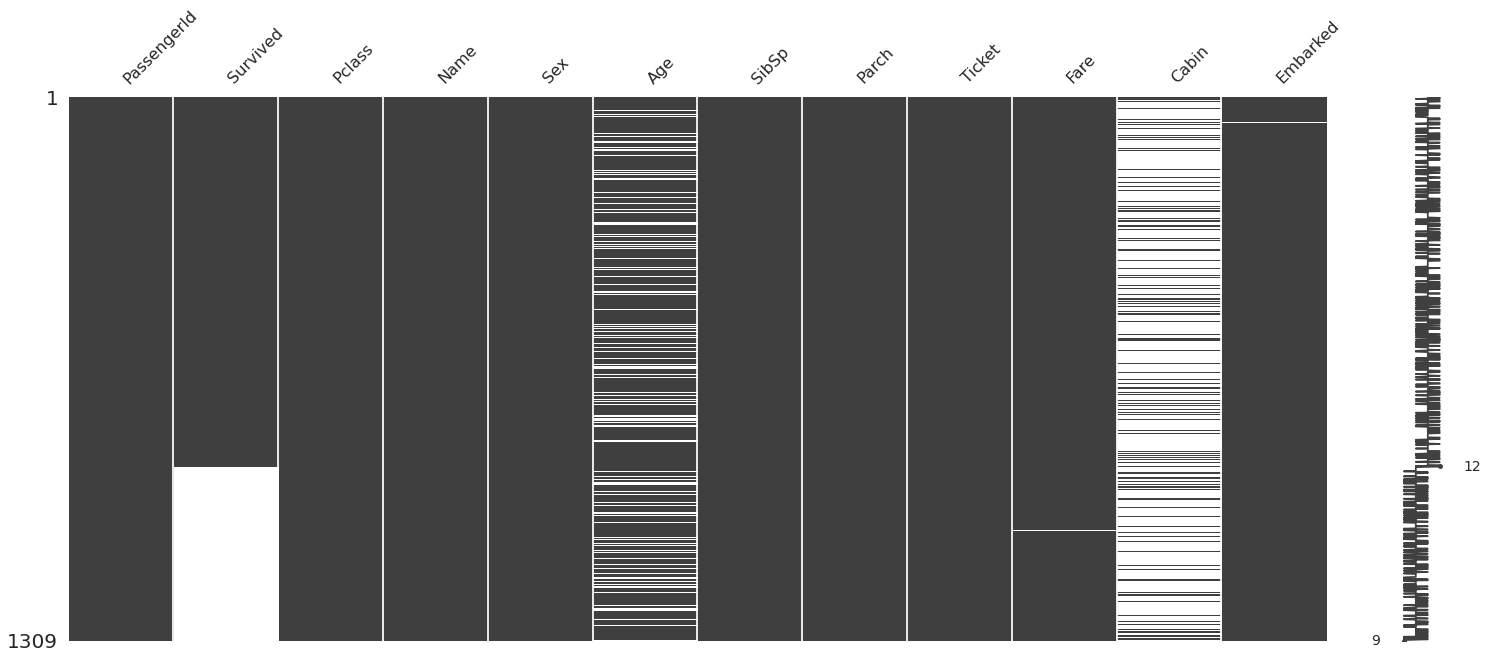

In [3]:
# missingno is a python library used to visualiza missing data
import missingno as msno
msno.matrix(full_data);

Null values in Survived column are of the test dataset. Age and Cabin columns contain many missing values.

In [4]:
print("Percentages of missing values: ")
full_data.isnull().mean().sort_values(ascending = False)

Percentages of missing values: 


Cabin          0.774637
Survived       0.319328
Age            0.200917
Embarked       0.001528
Fare           0.000764
Ticket         0.000000
Parch          0.000000
SibSp          0.000000
Sex            0.000000
Name           0.000000
Pclass         0.000000
PassengerId    0.000000
dtype: float64

Embarked and Fare have less than 1% missing values.So, we will simply fill them with mode and median.
To fill missing Age values I will find most correlated factor with age.

In [5]:
from statistics import mode
full_data["Embarked"] = full_data["Embarked"].fillna(mode(full_data["Embarked"]))

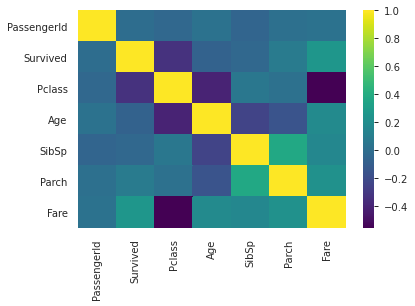

In [6]:
sns.heatmap(full_data.corr(),cmap='viridis');

So, we will fill Age and Fare column with help of Pclass feature.

In [7]:
full_data['Fare'] = full_data.groupby("Pclass")['Fare'].transform(lambda x: x.fillna(x.median()))
full_data['Age'] = full_data.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))

In [8]:
full_data['Cabin'].isna().sum()/len(full_data)

0.774637127578304

Almost 3/4th data is missing in Cabin feature.So, we will drop this column.

In [9]:
full_data.drop('Cabin',axis=1,inplace=True)

In [10]:
full_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1309 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1309 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1309 non-null   float64
 10  Embarked     1309 non-null   object 
dtypes: float64(3), int64(4), object(4)
memory usage: 122.7+ KB


## 1.2 Converting categorical columns.

Now we will convert categorical columns into numerical using dummy variables.

In [11]:
embarked = pd.get_dummies(full_data[['Embarked','Sex']],drop_first=True)
full_data = pd.concat([full_data,embarked],axis=1)

We will drop PassengerId and Ticket column as it doesn't seem important.Name too is not of much significance but salutation can be of importance.

In [12]:
Name1 = full_data['Name'].apply(lambda x : x.split(',')[1])

In [13]:
full_data['Title'] = Name1.apply(lambda x : x.split('.')[0])

In [14]:
full_data['Title'].value_counts(normalize=True)*100

 Mr              57.830405
 Miss            19.862490
 Mrs             15.049656
 Master           4.660046
 Dr               0.611154
 Rev              0.611154
 Col              0.305577
 Ms               0.152788
 Mlle             0.152788
 Major            0.152788
 Sir              0.076394
 the Countess     0.076394
 Jonkheer         0.076394
 Mme              0.076394
 Lady             0.076394
 Dona             0.076394
 Don              0.076394
 Capt             0.076394
Name: Title, dtype: float64

Except first four titles all form less than 1% of the data.So, we will combine them into one category and then form dummy variables.

In [15]:
full_data['Title'] = full_data['Title'].replace([ ' Don', ' Rev', ' Dr', ' Mme',' Ms', ' Major', ' Lady', ' Sir', ' Mlle', ' Col', ' Capt',' the Countess', ' Jonkheer', ' Dona'], 'Other')

In [16]:
full_data['Title'].unique()

array([' Mr', ' Mrs', ' Miss', ' Master', 'Other'], dtype=object)

In [17]:
embarked = pd.get_dummies(full_data['Title'],drop_first=True)
full_data = pd.concat([full_data,embarked],axis=1)

In [18]:
full_data.drop(['PassengerId','Name','Sex','Ticket','Title','Embarked'],axis=1,inplace=True)

In [19]:
full_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1309 entries, 0 to 417
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    float64
 1   Pclass      1309 non-null   int64  
 2   Age         1309 non-null   float64
 3   SibSp       1309 non-null   int64  
 4   Parch       1309 non-null   int64  
 5   Fare        1309 non-null   float64
 6   Embarked_Q  1309 non-null   uint8  
 7   Embarked_S  1309 non-null   uint8  
 8   Sex_male    1309 non-null   uint8  
 9    Miss       1309 non-null   uint8  
 10   Mr         1309 non-null   uint8  
 11   Mrs        1309 non-null   uint8  
 12  Other       1309 non-null   uint8  
dtypes: float64(3), int64(3), uint8(7)
memory usage: 80.5 KB


Now, let's retrieve our training and test data. And then convert each feature to integer.

In [20]:
test = full_data[full_data['Survived'].isna()].drop(['Survived'], axis = 1)
train = full_data[full_data['Survived'].notna()]

In [21]:
train = train.astype(np.int64)
test = test.astype(np.int64)

In [22]:
train.shape,test.shape

((891, 13), (418, 12))

# 2.Exploratory data analysis

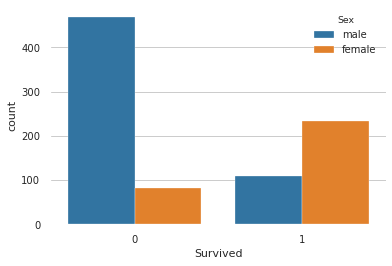

In [23]:
sns.countplot(x='Survived',data=train_data,hue='Sex');

Somehow, those who survived had more ratio of females and vice versa.  ;)

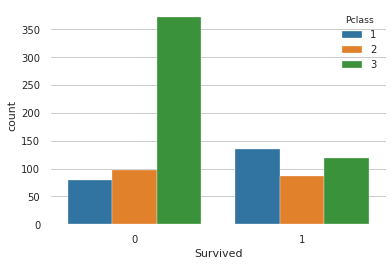

In [24]:
sns.countplot(x='Survived',data=train_data,hue='Pclass');

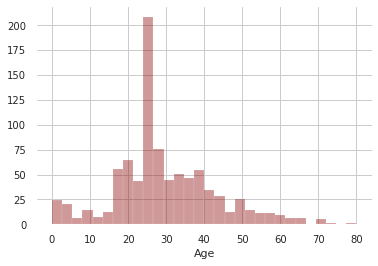

In [25]:
sns.distplot(train['Age'],kde=False,color='darkred',bins=30);

Mostly people on board were aged between 20-40.

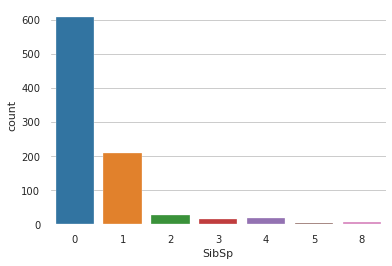

In [26]:
sns.countplot(x='SibSp',data=train);

Mostly people on board were without their siblings or spouse.

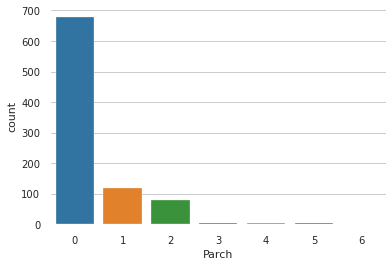

In [27]:
sns.countplot(x='Parch',data=train);

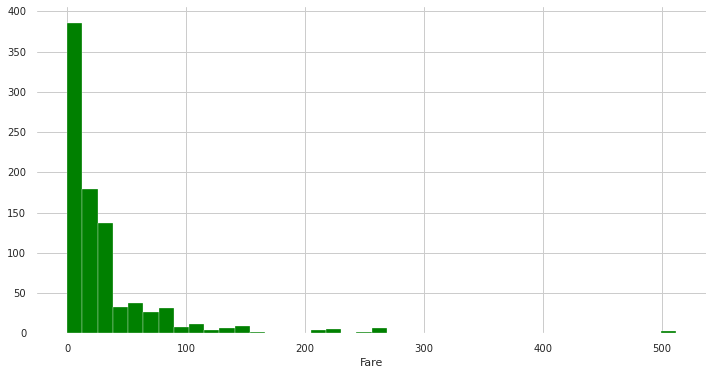

In [28]:
train['Fare'].hist(color='green',bins=40,figsize=(12,6))
plt.xlabel('Fare');

Fare seems to be mostly below 100.

# 3. Applying Logistic Regression.

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(train.drop(['Survived'], axis = 1), 
                                                    train['Survived'], test_size = 0.2, 
                                                    random_state = 2)

In [30]:
logisticRegression = LogisticRegression(max_iter = 10000)
logisticRegression.fit(X_train, y_train)
predictions = logisticRegression.predict(X_test)
print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

[[88 12]
 [26 53]]
              precision    recall  f1-score   support

           0       0.77      0.88      0.82       100
           1       0.82      0.67      0.74        79

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.79      0.79      0.78       179



Let's improve our accuracy by using N-fold cross-validation.

In [31]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score,cross_val_predict

In [32]:
kf = KFold(n_splits = 5)
score = cross_val_score(logisticRegression, train.drop('Survived', axis = 1),train['Survived'], cv = kf)
print(f"Accuracy after cross validation is {score.mean()*100}")

Accuracy after cross validation is 81.81846713953928


It has improved to 81%.


# 4. Applying deep neural network

In [33]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation,Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [34]:
model = Sequential()
model.add(Dense(units=12,activation='tanh'))
model.add(Dense(units=100,activation='tanh'))
model.add(Dropout(0.5))
model.add(Dense(units=100,activation='tanh'))
model.add(Dropout(0.5))
model.add(Dense(units=100,activation='tanh'))
model.add(Dropout(0.5))
model.add(Dense(units=1,activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam')

early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=25)

model.fit(x=X_train.values, 
          y=y_train.values, 
          epochs=600,
          validation_data=(X_test, y_test), verbose=1,
          callbacks=[early_stop]
          )

Train on 712 samples, validate on 179 samples
Epoch 1/600
712/712 [==============================] - 1s 1ms/sample - loss: 0.6812 - val_loss: 0.6475
Epoch 2/600
712/712 [==============================] - 0s 126us/sample - loss: 0.7008 - val_loss: 0.6854
Epoch 3/600
712/712 [==============================] - 0s 134us/sample - loss: 0.6761 - val_loss: 0.6657
Epoch 4/600
712/712 [==============================] - 0s 125us/sample - loss: 0.6535 - val_loss: 0.6738
Epoch 5/600
712/712 [==============================] - 0s 129us/sample - loss: 0.6338 - val_loss: 0.6480
Epoch 6/600
712/712 [==============================] - 0s 126us/sample - loss: 0.6542 - val_loss: 0.6719
Epoch 7/600
712/712 [==============================] - 0s 131us/sample - loss: 0.6223 - val_loss: 0.6620
Epoch 8/600
712/712 [==============================] - 0s 120us/sample - loss: 0.5909 - val_loss: 0.6544
Epoch 9/600
712/712 [==============================] - 0s 122us/sample - loss: 0.6207 - val_loss: 0.6503
Epoch 10/60

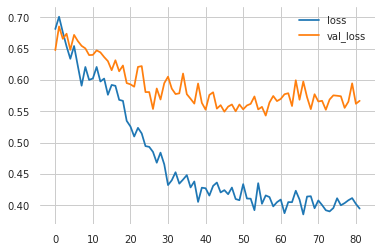

In [35]:
model_loss = pd.DataFrame(model.history.history)
model_loss.plot();

In [36]:
dnn_predictions = model.predict_classes(X_test)
print(classification_report(y_test,dnn_predictions))
print(confusion_matrix(y_test,dnn_predictions))

              precision    recall  f1-score   support

           0       0.73      0.89      0.80       100
           1       0.81      0.58      0.68        79

    accuracy                           0.75       179
   macro avg       0.77      0.74      0.74       179
weighted avg       0.76      0.75      0.75       179

[[89 11]
 [33 46]]


It provides less accuracy than logistic regression

# 5. Applying Random Forest.

In [37]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=100)
rfc.fit(X_train, y_train)
rfc_pred = rfc.predict(X_test)
print(classification_report(y_test,rfc_pred))
print(confusion_matrix(y_test,rfc_pred))

              precision    recall  f1-score   support

           0       0.81      0.87      0.84       100
           1       0.82      0.73      0.77        79

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

[[87 13]
 [21 58]]


In [38]:
param_grid = { 
    'criterion' : ['gini', 'entropy'],
    'n_estimators': [100, 300,500],
    'max_features': ['auto', 'log2'],
    'max_depth' : [3,5, 7,9]    
}

from sklearn.model_selection import GridSearchCV
randomForest_CV = GridSearchCV(estimator = rfc, param_grid = param_grid, cv = 5)
randomForest_CV.fit(X_train, y_train)
grid_pred = randomForest_CV.predict(X_test)
print(classification_report(y_test,grid_pred))
print(confusion_matrix(y_test,grid_pred))

              precision    recall  f1-score   support

           0       0.76      0.93      0.83       100
           1       0.88      0.62      0.73        79

    accuracy                           0.79       179
   macro avg       0.82      0.78      0.78       179
weighted avg       0.81      0.79      0.79       179

[[93  7]
 [30 49]]


In [39]:
randomForest_CV.best_params_

{'criterion': 'entropy',
 'max_depth': 7,
 'max_features': 'auto',
 'n_estimators': 300}

# 6. Applying XGBoost

In [40]:
from xgboost import plot_importance,XGBClassifier

In [41]:
xgb = XGBClassifier().fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
print(confusion_matrix(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

[[88 12]
 [23 56]]
              precision    recall  f1-score   support

           0       0.79      0.88      0.83       100
           1       0.82      0.71      0.76        79

    accuracy                           0.80       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.80      0.80       179



Feature Importance


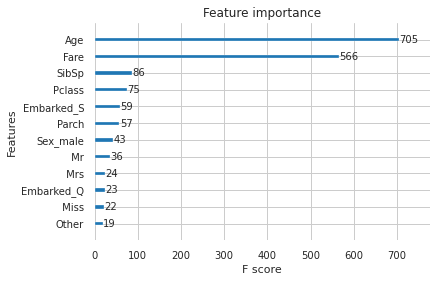

In [42]:
print("Feature Importance")
plot_importance(xgb);

# 7. Submitting predictions.

In [43]:
test['Survived'] = logisticRegression.predict(test)
test['PassengerId'] = test_data['PassengerId']
test[['PassengerId', 'Survived']].to_csv('lm_submission.csv', index = False)

In [44]:
test['Survived'] = model.predict_classes(test.iloc[:,:12])
test[['PassengerId', 'Survived']].to_csv('dnn_submission.csv', index = False)

In [45]:
test['Survived'] = rfc.predict(test.iloc[:,:12])
test[['PassengerId', 'Survived']].to_csv('rfc_submission.csv', index = False)

In [46]:
test['Survived'] = xgb.predict(test.iloc[:,:12])
test[['PassengerId', 'Survived']].to_csv('xgb_submission.csv', index = False)